In [26]:
# python 3.13.1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score



In [2]:
file=pd.read_csv('SQLiV3.csv')
file

,Sentence,Label
0,""" or pg_sleep ( __TIME__ ) --",1
1,create user name identified by pass123 tempora...,NaN
2,AND 1 = utl_inaddr.get_host_address ( ...,1
3,select * from users where id = '1' or @ @1 ...,1
4,"select * from users where id = 1 or 1#"" ( ...",1
...,...,...
30914,DELETE FROM door WHERE grow = 'small',0
30915,DELETE FROM tomorrow,0
30916,SELECT wide ( s ) FROM west,0
30917,SELECT * FROM ( SELECT slide FROM breath ),0


In [3]:
file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30919 entries, 0 to 30918
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Sentence  30904 non-null  object
 1   Label     30664 non-null  object
dtypes: object(2)
memory usage: 483.2+ KB


In [4]:
file['Sentence'].isnull().sum()

np.int64(15)

In [6]:
file['Label'].isnull().sum()

np.int64(255)

In [ ]:
file = pd.read_csv('SQLiV3.csv', encoding='latin-1')

print("Original shape:", file.shape)

file["Label"] = pd.to_numeric(file["Label"], errors='coerce')

print("After convert:", file["Label"].unique())

file = file[file["Label"].isin([0,1])]
print("After label filter:", file.shape)

file.dropna(subset=['Sentence', 'Label'], inplace=True)
print("After dropna:", file.shape)

file["Sentence"] = file["Sentence"].astype(str)
file = file[file["Sentence"].str.strip() != ""]

print("After cleaning:", file.shape)

features = file["Sentence"].values.astype("U")
labels = file["Label"]

print("Final Features:", len(features))
print("Final Labels:", len(labels))

Original shape: (30919, 2)
After convert: [ 1. nan  0.]
After label filter: (30609, 2)
After dropna: (30609, 2)
After cleaning: (30608, 2)
Final Features: 30608
Final Labels: 30608


In [20]:
print(file["Label"].unique())


[1. 0.]


In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

vector = TfidfVectorizer(
    analyzer="char",
    ngram_range=(2,5)
)

features_vector = vector.fit_transform(features)


In [ ]:
features_vector[0]


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 105 stored elements and shape (1, 280639)>

In [22]:
x_train,x_test,y_train,y_test=train_test_split(features_vector,labels,test_size=0.2,random_state=42)

In [23]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [24]:
rf_predictions = rf_model.predict(x_test)

In [27]:
accuracy_score(y_test, rf_predictions)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))

Random Forest Accuracy: 0.9962430578242405


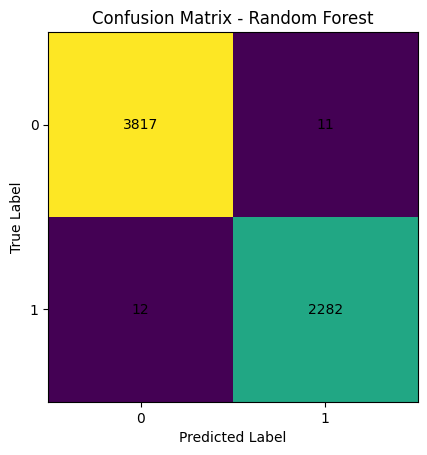

In [28]:
cm_rf = confusion_matrix(y_test, rf_predictions)
plt.figure()
plt.imshow(cm_rf)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(np.arange(2))
plt.yticks(np.arange(2))
for i in range(cm_rf.shape[0]):
    for j in range(cm_rf.shape[1]):
        plt.text(j, i, cm_rf[i, j], ha="center", va="center")
plt.show()        

In [30]:
cm_rf

array([[3817,   11],
       [  12, 2282]])

In [29]:
queries = [
    "SELECT * FROM users WHERE id=5",
    "admin' OR 1=1 --",
    "SELECT name FROM customers",
    "' UNION SELECT username,password FROM users --"
]

queries_vec = vector.transform(queries)

predictions = rf_model.predict(queries_vec)

for q, p in zip(queries, predictions):
    print(q, "→", "Attack" if p==1 else "Normal")

SELECT * FROM users WHERE id=5 → Normal
admin' OR 1=1 -- → Attack
SELECT name FROM customers → Normal
' UNION SELECT username,password FROM users -- → Normal


In [31]:
import joblib

joblib.dump(rf_model, "sqli_model.pkl")
joblib.dump(vector, "vectorizer.pkl")

print("Model saved")

Model saved
